# Multi-Method VaR Engine
**Portfolio:** RELIANCE, TCS, HDFCBANK, INFY, ICICIBANK  
**Methods:** Historical | Parametric | Monte Carlo  
**Author:** Mahek | FRM  
**Data:** NSE via yfinance | 2023–2024

# 1. Import Libraries and Data Collection

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

tickers = ['Reliance.ns', 'tcs.ns', 'hdfcbank.ns', 'infy.ns', 'icicibank.ns']

data = yf.download(tickers, start='2023-01-01', end='2024-12-31') ['Close']
data.columns = ['Reliance', 'tcs', 'hdfcbank','infy', 'icicibank']

print(data.shape)
print(data.head())

[*********************100%***********************]  5 of 5 completed

(490, 5)
              Reliance         tcs     hdfcbank         infy    icicibank
Date                                                                     
2023-01-02  783.677856  880.647400  1397.702148  1175.889648  2932.793945
2023-01-03  788.802368  879.573914  1396.372437  1167.284668  2977.666016
2023-01-04  774.704102  877.378296  1370.921875  1149.709595  2980.632812
2023-01-05  769.724060  857.910339  1352.946289  1147.655273  2977.440430
2023-01-06  767.173889  849.078857  1328.459106  1158.086304  2887.922607


## 2. Returns & Portfolio Construction

In [2]:
returns = data.pct_change()*100
returns = returns.dropna()

print(returns.shape)
print(returns.describe())

(489, 5)
         Reliance         tcs    hdfcbank        infy   icicibank
count  489.000000  489.000000  489.000000  489.000000  489.000000
mean     0.030880    0.083932    0.068084    0.013350    0.068403
std      1.248358    1.155284    1.454276    1.282510    1.240803
min     -8.435822   -7.633631   -9.422691   -7.485140   -4.219133
25%     -0.554092   -0.490360   -0.705320   -0.780037   -0.589534
50%      0.076434    0.090521   -0.016076    0.027423    0.004659
75%      0.672312    0.659328    0.841955    0.725150    0.680151
max      4.628666    4.716128    7.934012    7.019207    6.632796


In [3]:
weights = np.array ([0.2,0.2,0.2,0.2,0.2])

returns['Portfolio'] = returns[['Reliance','tcs', 'hdfcbank', 'infy', 'icicibank']].dot(weights)

print(f"Portfolio mean return: {returns['Portfolio'].mean():.3f}%")
print(f"Portfolio volatility: {returns['Portfolio'].std():.3f}%")
print(f"nIndividual volatilities:")
print(returns[['Reliance','tcs', 'hdfcbank', 'infy','icicibank']].std())

Portfolio mean return: 0.053%
Portfolio volatility: 0.852%
nIndividual volatilities:
Reliance     1.248358
tcs          1.155284
hdfcbank     1.454276
infy         1.282510
icicibank    1.240803
dtype: float64


## 3. VaR Methods

### 3.1 Historical VaR

In [4]:
portfolio_value = 1000000

hist_var_95 = returns['Portfolio'].quantile(0.05)
hist_var_99 = returns['Portfolio'].quantile(0.01)

print("=== HISTORICAL VAR ===")
print(f"95% VaR: {hist_var_95: .2f}%  ->   ${abs(hist_var_95/100 * portfolio_value):,.0f}")
print(f"99% VaR: {hist_var_99: .2f}%  ->   ${abs(hist_var_99/100 * portfolio_value):,.0f}")


=== HISTORICAL VAR ===
95% VaR: -1.32%  ->   $13,245
99% VaR: -2.10%  ->   $20,996


### 3.2 Parametric VaR

In [5]:
from scipy import stats
mean = returns['Portfolio'].mean()
std = returns['Portfolio'].std()

z_95 = stats.norm.ppf(0.05)
z_99 = stats.norm.ppf(0.01)

param_var_95 = mean + z_95 * std
param_var_99 = mean + z_99 * std

print("=== HISTORICAL VAR ===")
print(f"95% VaR: {param_var_95: .2f}%  ->   ${abs(param_var_95/100 * portfolio_value):,.0f}")
print(f"99% VaR: {param_var_99: .2f}%  ->   ${abs(param_var_99/100 * portfolio_value):,.0f}")


=== HISTORICAL VAR ===
95% VaR: -1.35%  ->   $13,478
99% VaR: -1.93%  ->   $19,281


### 3.3 Monte Carlo VaR

In [6]:
np.random.seed(42)
simulations = 10000

# Simulate 10,000 possible daily returns
mc_returns = np.random.normal(mean, std, simulations)

mc_var_95 = np.percentile(mc_returns, 5)
mc_var_99 = np.percentile(mc_returns, 1)

print("=== MONTE CARLO VAR ===")
print(f"Simulations: {simulations:,}")
print(f"95% VaR: {mc_var_95: .2f}%  ->   ${abs(mc_var_95/100 * portfolio_value):,.0f}")
print(f"99% VaR: {mc_var_99: .2f}%  ->   ${abs(mc_var_99/100 * portfolio_value):,.0f}")

=== MONTE CARLO VAR ===
Simulations: 10,000
95% VaR: -1.36%  ->   $13,563
99% VaR: -1.92%  ->   $19,232


### 3.4 Monte Carlo VaR v/s Actual Returns

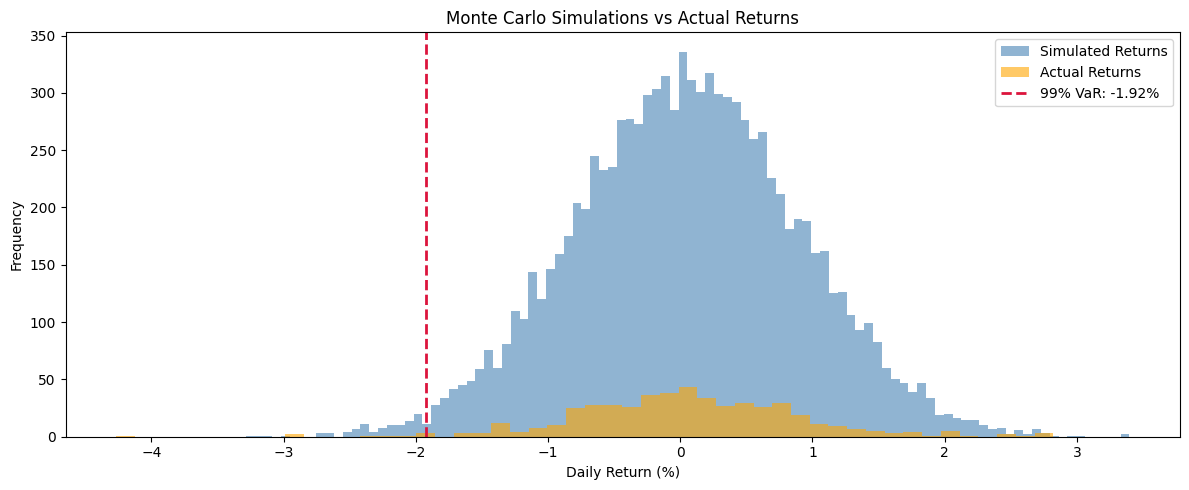

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(mc_returns, bins=100, color='steelblue', alpha=0.6, label='Simulated Returns')
ax.hist(returns['Portfolio'], bins=50, color='orange', alpha=0.6, label='Actual Returns')
ax.axvline(mc_var_99, color='crimson', linewidth=2, linestyle='--', label=f'99% VaR: {mc_var_99:.2f}%')

ax.set_title('Monte Carlo Simulations vs Actual Returns')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Results Comparison

In [8]:
print("=" * 55)
print(f"{'PORTFOLIO VAR SUMMARY':^55}")
print(f"{'Portfolio Value: ₹10,00,000':^55}")
print("=" * 55)
print(f"{'Method':<20} {'95% VaR':>17} {'99% VaR':>18}")
print("-" * 55)
print(f"{'Historical':<20} {hist_var_95:>14.2f}% {hist_var_99:>14.2f}%")
print(f"{'Parametric':<20} {param_var_95:>14.2f}% {param_var_99:>14.2f}%")
print(f"{'Monte Carlo':<20} {mc_var_95:>14.2f}% {mc_var_99:>14.2f}%")
print("=" * 55)

                 PORTFOLIO VAR SUMMARY                 
              Portfolio Value: ₹10,00,000              
Method                         95% VaR            99% VaR
-------------------------------------------------------
Historical                    -1.32%          -2.10%
Parametric                    -1.35%          -1.93%
Monte Carlo                   -1.36%          -1.92%
